Read data from .root file

In [142]:
import uproot 
import hist
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import itertools
import numpy as np
import pandas as pd

# Open the ROOT file and read the TTree
with uproot.open("./Outputs/tree_padplane_7Li_d_p.root") as file:
    tree_RAW = file["PadPlane_Tree"].arrays(library="pd")



In [143]:
tree_RAW.describe()

,Qave,Qtotal,ThetaLight,TL,phiSum,ThetaHeavy,Ex,pTLight_dp,pTHeavy_dp,pTLight_dd,pTHeavy_dd
count,5531.000000,5531.000000,5531.000000,5531.000000,5531.000000,5531.000000,5531.000000,5531.000000,5531.000000,5531.000000,5531.000000
mean,739.799920,65887.592660,79.182743,106.240424,-26.764219,5.622258,5.542193,42.979303,77.433593,68.703369,77.167347
std,155.366805,15362.036975,22.291847,38.001168,57.535831,3.322259,1.712894,8.120064,43.595879,13.226782,44.248378
min,474.869232,35374.000000,2.760027,28.897919,-179.975910,0.000000,2.003456,2.658541,0.000000,4.277892,0.000000
25%,617.393097,53437.000000,72.078949,73.269012,-55.717152,3.503752,4.646171,38.498543,48.820217,61.229748,48.368658
50%,718.573425,66735.000000,76.720215,105.578033,-5.852478,5.644239,5.689610,44.352516,78.464203,70.903283,77.798798
75%,836.941559,77835.500000,90.997551,135.227745,1.321487,7.279473,6.195953,49.390097,100.239817,79.212591,100.038747
max,1658.845581,101437.000000,139.117462,251.686340,148.838928,52.504055,10.280961,56.768589,627.095004,91.455039,613.389437


In [144]:
#Drop all rows that have a value = -1.0f in any column to avoid any potential issues with them in PCA
rows_to_drop = tree_RAW[(tree_RAW == -1.0).any(axis=1)]
print("\nDropping rows with -1.0 in any column:")
print(rows_to_drop)
tree = tree_RAW[~(tree_RAW == -1.0).any(axis=1)]


Dropping rows with -1.0 in any column:
Empty DataFrame
Columns: [Qave, Qtotal, ThetaLight, TL, phiSum, ThetaHeavy, Ex, pTLight_dp, pTHeavy_dp, pTLight_dd, pTHeavy_dd]
Index: []


Remove all the NaNs in the tree

In [145]:
print('Check for NaN values in normalized numeric columns:')
numeric_cols = tree.select_dtypes(include=[np.number]).columns
nan_counts = tree[numeric_cols].isna().sum()
print(nan_counts)
#Remove nans
tree = tree.dropna(subset=numeric_cols)
print('After dropping NaN values, check for NaN again:')
print(tree[numeric_cols].isna().sum())

Check for NaN values in normalized numeric columns:
Qave          0
Qtotal        0
ThetaLight    0
TL            0
phiSum        0
ThetaHeavy    0
Ex            0
pTLight_dp    0
pTHeavy_dp    0
pTLight_dd    0
pTHeavy_dd    0
dtype: int64
After dropping NaN values, check for NaN again:
Qave          0
Qtotal        0
ThetaLight    0
TL            0
phiSum        0
ThetaHeavy    0
Ex            0
pTLight_dp    0
pTHeavy_dp    0
pTLight_dd    0
pTHeavy_dd    0
dtype: int64


In [146]:
#Add sin and cosin of phi and theta
tree["SinTheta"]=np.sin(tree["ThetaLight"] * np.pi / 180.0)
tree["CosTheta"]=np.cos(tree["ThetaLight"] * np.pi / 180.0)

In [147]:
# Get all the variables squared
tree["Qave2"] = tree["Qave"] ** 2
tree["Qtotal2"] = tree["Qtotal"] ** 2
tree["ThetaLight2"] = tree["ThetaLight"] ** 2
tree["TL2"] = tree["TL"] ** 2
#tree["RawTL2"] = tree["Light_fRawTL"] ** 2
#tree["PhiLight2"] = tree["PhiLight"] ** 2
#tree["chargePerVoxelLight2"] = tree["chargePerVoxelLight"] ** 2
#tree["qRatio2"] = tree["qRatio"] ** 2
#tree["lastThirdQ2"] = tree["lastThirdQ"] ** 2
#tree["nVoxelsLight2"] = tree["nVoxelsLight"] ** 2
#tree["zDrift2"] = tree["zDrift"] ** 2

#tree["CosPhi2"] = tree["CosPhi"] ** 2
#tree["SinPhi2"] = tree["SinPhi"] ** 2
tree["CosTheta2"] = tree["CosTheta"] ** 2
tree["SinTheta2"] = tree["SinTheta"] ** 2

tree["pTHeavy_dp2"] = tree["pTHeavy_dp"] ** 2
tree["pTLight_dp2"] = tree["pTLight_dp"] ** 2
tree["pTHeavy_dd2"] = tree["pTHeavy_dd"] ** 2
tree["pTLight_dd2"] = tree["pTLight_dd"] ** 2

In [148]:
#Get all the variables cubed
tree["Qave3"] = tree["Qave"] ** 3
tree["Qtotal3"] = tree["Qtotal"] ** 3
tree["ThetaLight3"] = tree["ThetaLight"] ** 3
tree["TL3"] = tree["TL"] ** 3
#tree["fRawTL3"] = tree["fLight_fRawTL"] ** 3
#tree["PhiLight3"] = tree["PhiLight"] ** 3
#tree["chargePerVoxelLight3"] = tree["chargePerVoxelLight"] ** 3
#tree["qRatio3"] = tree["qRatio"] ** 3
#tree["lastThirdQ3"] = tree["lastThirdQ"] ** 3
#tree["nVoxelsLight3"] = tree["nVoxelsLight"] ** 3
#tree["zDrift3"] = tree["zDrift"] ** 3

#tree["CosPhi3"] = tree["CosPhi"] ** 3
#tree["SinPhi3"] = tree["SinPhi"] ** 3
tree["CosTheta3"] = tree["CosTheta"] ** 3
tree["SinTheta3"] = tree["SinTheta"] ** 3

tree["pTHeavy_dp3"] = tree["pTHeavy_dp"] ** 3
tree["pTLight_dp3"] = tree["pTLight_dp"] ** 3
tree["pTHeavy_dd3"] = tree["pTHeavy_dd"] ** 3
tree["pTLight_dd3"] = tree["pTLight_dd"] ** 3

In [149]:
# Get all the variables multiplied by each other
# Multiplication is commutative, so we generate each unordered pair once.

mul_vars = [
    "Qave", "Qtotal", "ThetaLight", "TL",
      "SinTheta", "CosTheta", "pTLight_dp", "pTLight_dd"]

for a, b in itertools.combinations(mul_vars, 2):
    tree[f"{a}_{b}"] = tree[a] * tree[b]

# Get all the variables divided by each other
# Division is not commutative, so we generate both ordered directions.
div_vars = [
    "Qave", "Qtotal", "ThetaLight", "TL",
    "phiSum", "SinTheta", "CosTheta", "pTLight_dp", "pTLight_dd"
]

for numerator in div_vars:
    for denominator in div_vars:
        if numerator == denominator:
            continue
        column_name = f"{numerator}_{denominator}_div"
        tree[column_name] = tree[numerator] / tree[denominator]

/tmp/ipykernel_72112/1037330068.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  tree[column_name] = tree[numerator] / tree[denominator]
/tmp/ipykernel_72112/1037330068.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  tree[column_name] = tree[numerator] / tree[denominator]
/tmp/ipykernel_72112/1037330068.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) inste

In [150]:
#Add Charge / cosTheta
tree["ChargeOverCosTheta"]=tree["Qtotal"]/np.cos(tree["ThetaLight"] * np.pi / 180.0)

/tmp/ipykernel_72112/3257257462.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  tree["ChargeOverCosTheta"]=tree["Qtotal"]/np.cos(tree["ThetaLight"] * np.pi / 180.0)


Check for NaNs

In [151]:
# =========================
# 1. NaNs por columna
# =========================
num_cols = tree.select_dtypes(include=["number"]).columns
nan_counts = tree[num_cols].isna().sum()

print("NaN per column:")
print(nan_counts[nan_counts > 0].sort_values(ascending=False))

# =========================
# 2. filas que tienen al menos un NaN
# =========================
rows_with_nan = tree[num_cols].isna().any(axis=1)

print("\nNumber of rows with at least one NaN:")
print(rows_with_nan.sum())

print("Total rows before dropna:")
print(len(tree))

# =========================
# 3. ver proporción
# =========================
print("\nFraction of affected rows:")
print(rows_with_nan.mean())

NaN per column:
Series([], dtype: int64)

Number of rows with at least one NaN:
0
Total rows before dropna:
5531

Fraction of affected rows:
0.0


Histogram of Ex

(array([ 87., 179., 124.,  70.,  59.,  79.,  93.,  90.,  61.,  77.,  78.,
         66.,  78.,  83.,  76.,  87.,  86.,  89.,  88.,  98., 239., 591.,
        741., 513., 257., 135., 102.,  91.,  71.,  84.,  59.,  68.,  81.,
         68.,  65.,  70.,  84.,  64.,  76.,  62.,  56.,  53.,  36.,  32.,
         28.,  25.,  15.,  10.,   3.,   4.]),
 array([ 2.00345649,  2.16900658,  2.33455666,  2.50010675,  2.66565684,
         2.83120692,  2.99675701,  3.16230709,  3.32785718,  3.49340727,
         3.65895735,  3.82450744,  3.99005752,  4.15560761,  4.3211577 ,
         4.48670778,  4.65225787,  4.81780795,  4.98335804,  5.14890813,
         5.31445821,  5.4800083 ,  5.64555838,  5.81110847,  5.97665856,
         6.14220864,  6.30775873,  6.47330881,  6.6388589 ,  6.80440898,
         6.96995907,  7.13550916,  7.30105924,  7.46660933,  7.63215941,
         7.7977095 ,  7.96325959,  8.12880967,  8.29435976,  8.45990984,
         8.62545993,  8.79101002,  8.9565601 ,  9.12211019,  9.28766027,
 

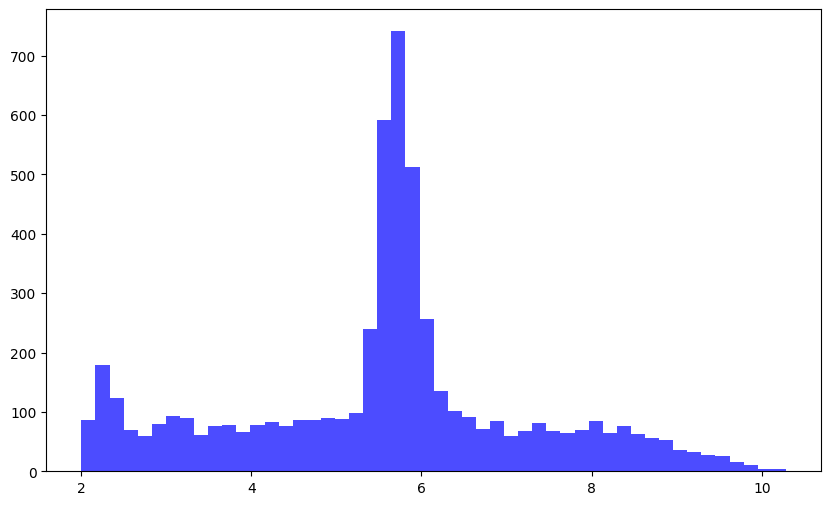

In [152]:
plt.figure(figsize=(10, 6))
plt.hist(tree["Ex"], bins=50, color='blue', alpha=0.7)

DO THE PCA

In [153]:

# select numeric columns only
num_cols = tree.select_dtypes(include=["number"]).columns
# compute population standard deviation (ddof=0) and avoid zeros
stds = tree[num_cols].std(ddof=0)
stds = stds.replace(0, 1.0)
# create normalized copy
df_norm = tree.copy()
df_norm[num_cols] = tree[num_cols] / stds
print('Normalized numeric columns by std (ddof=0):')
print(stds)

# inspect first rows
print(df_norm.head())

Normalized numeric columns by std (ddof=0):
Qave                         1.553528e+02
Qtotal                       1.536065e+04
ThetaLight                   2.228983e+01
TL                           3.799773e+01
phiSum                       5.753063e+01
                                 ...     
pTLight_dd_phiSum_div        5.572474e+02
pTLight_dd_SinTheta_div      8.970810e+00
pTLight_dd_CosTheta_div      2.994687e+03
pTLight_dd_pTLight_dp_div    9.267218e-03
ChargeOverCosTheta           2.555707e+06
Length: 134, dtype: float64
       Qave    Qtotal  ThetaLight        TL    phiSum  ThetaHeavy        Ex  \
0  5.223713  3.455453    2.593628  1.907024 -0.812052    0.806094  4.334954   
1  5.497223  4.010703    3.334216  2.014484 -1.311786    1.260426  3.532859   
2  5.006437  3.809605    3.535885  2.145132 -0.040124    0.870789  3.405750   
3  4.267698  4.022031    3.760567  2.764504 -0.464498    0.197866  3.136170   
4  3.681083  4.731962    3.416693  3.646994  0.010057    2.313164  3.32

In [154]:
df_norm.describe()

,Qave,Qtotal,ThetaLight,TL,phiSum,ThetaHeavy,Ex,pTLight_dp,pTHeavy_dp,pTLight_dd,...,pTLight_dp_pTLight_dd_div,pTLight_dd_Qave_div,pTLight_dd_Qtotal_div,pTLight_dd_ThetaLight_div,pTLight_dd_TL_div,pTLight_dd_phiSum_div,pTLight_dd_SinTheta_div,pTLight_dd_CosTheta_div,pTLight_dd_pTLight_dp_div,ChargeOverCosTheta
count,5531.000000,5531.000000,5531.000000,5531.000000,5531.000000,5531.000000,5531.000000,5531.000000,5531.000000,5531.000000,...,5531.000000,5531.000000,5531.000000,5531.000000,5531.000000,5531.000000,5531.000000,5531.000000,5531.000000,5531.000000
mean,4.762065,4.289376,3.552415,2.795967,-0.465217,1.692453,3.235865,5.293454,1.776328,5.194732,...,171.447815,2.877984,5.117209,4.042915,3.263256,-0.007007,8.390619,0.017298,172.366912,0.022646
std,1.000090,1.000090,1.000090,1.000090,1.000090,1.000090,1.000090,1.000090,1.000090,1.000090,...,1.000090,1.000090,1.000090,1.000090,1.000090,1.000090,1.000090,1.000090,1.000090,1.000090
min,3.056716,2.302898,0.123825,0.760517,-3.128349,0.000000,1.169738,0.327434,0.000000,0.323456,...,169.446360,0.186819,0.268771,1.188942,0.113565,-31.962690,5.546882,-40.021368,167.786973,-40.873661
25%,3.974137,3.478825,3.233714,1.928247,-0.968478,1.054725,2.712714,4.741591,1.119937,4.629643,...,170.679344,2.084077,4.604013,3.336609,2.596647,-0.012716,7.589433,-0.024266,171.735104,-0.025565
50%,4.625431,4.344543,3.441938,2.778535,-0.101728,1.699070,3.321936,5.462583,1.799971,5.361069,...,171.203691,2.803822,5.097716,4.229908,3.024412,-0.001621,8.512959,0.073360,172.606854,0.076103
75%,5.387362,5.067202,4.082469,3.558837,0.022970,2.191319,3.617570,6.083026,2.299504,5.989345,...,172.072743,3.668835,5.702230,4.742613,3.863012,0.001875,9.187727,0.113267,173.137122,0.124226
max,10.677928,6.603693,6.241297,6.623720,2.587125,15.805150,6.002642,6.991782,14.385573,6.915009,...,176.121721,5.287158,8.823528,6.811819,7.830583,61.415425,11.094327,10.950150,174.396962,9.657972


Check again for NaNs

In [155]:
# =========================
# 1. NaNs por columna
# =========================
nan_counts = df_norm[num_cols].isna().sum()

print("NaN per column:")
print(nan_counts[nan_counts > 0].sort_values(ascending=False))

# =========================
# 2. filas que tienen al menos un NaN
# =========================
rows_with_nan = df_norm[num_cols].isna().any(axis=1)

print("\nNumber of rows with at least one NaN:")
print(rows_with_nan.sum())

print("Total rows before dropna:")
print(len(df_norm))

# =========================
# 3. ver proporción
# =========================
print("\nFraction of affected rows:")
print(rows_with_nan.mean())

NaN per column:
Series([], dtype: int64)

Number of rows with at least one NaN:
0
Total rows before dropna:
5531

Fraction of affected rows:
0.0


In [156]:
n_comp = 4
pca=PCA(n_components=n_comp)
num_cols = df_norm.select_dtypes(include=["number"]).columns
pca.fit(df_norm[num_cols])
print('Explained variance ratio:', pca.explained_variance_ratio_)
print('Principal components:\n', pca.components_)


Explained variance ratio: [0.33542187 0.27069029 0.0811443  0.0593836 ]
Principal components:
 [[-1.33006766e-01  1.32254230e-01 -5.66478861e-02  1.43882979e-01
   2.00917040e-02  4.82089883e-02  4.41923569e-02  9.23301508e-02
   4.80690658e-02  9.45904494e-02  4.83171722e-02  7.24941592e-03
   5.96234971e-02 -1.27759180e-01  1.30134816e-01 -6.53206206e-02
   1.38862031e-01 -9.95603215e-03  9.95603215e-03  3.23915825e-02
   1.02444854e-01  3.22904614e-02  1.04386237e-01 -1.18128673e-01
   1.26413338e-01 -6.99750709e-02  1.31243890e-01  2.77968970e-02
   1.18315067e-02  2.09961516e-02  1.08470354e-01  2.13908482e-02
   1.10072727e-01  3.12188669e-02 -1.14284288e-01  1.34051243e-01
  -1.09564156e-01  4.60910606e-02 -5.59141748e-02 -5.16369447e-02
   4.88283865e-02  1.39703506e-01  1.12831376e-01  7.31886765e-02
   1.26249954e-01  1.26639869e-01  9.42125952e-02 -4.31254931e-02
   7.21707344e-02  1.08403431e-02  1.33129840e-02  1.31920808e-01
   8.17561947e-02  1.34497267e-01  1.34577200e-

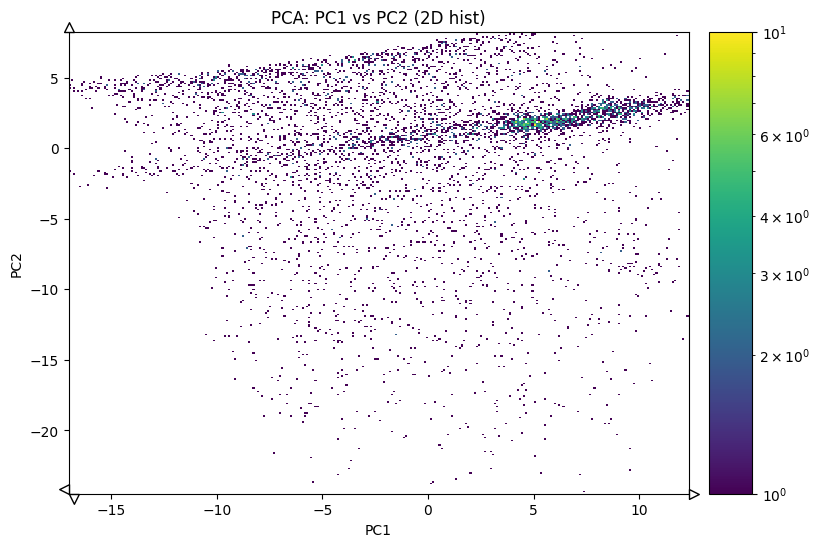

In [157]:
# 2D histogram of the first two PCA components using `hist`
pca_result = pca.transform(df_norm[num_cols])
pc1 = pca_result[:, 0]
pc2 = pca_result[:, 1]
# use robust percentile-driven ranges to avoid extreme outliers
xmin, xmax = np.percentile(pc1, [0.5, 99.5])
ymin, ymax = np.percentile(pc2, [0.5, 99.5])
# build a 2D hist with the `hist` package
h2 = hist.Hist(hist.axis.Regular(300, xmin, xmax, name="PC1"),
               hist.axis.Regular(300, ymin, ymax, name="PC2"))
h2.fill(PC1=pc1, PC2=pc2)
# draw with matplotlib (use pcolormesh from the histogram edges and values)
fig, ax = plt.subplots(figsize=(8,6))
h2.plot(ax=ax,norm=mcolors.LogNorm(), cmap='viridis')

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('PCA: PC1 vs PC2 (2D hist)')
plt.show()

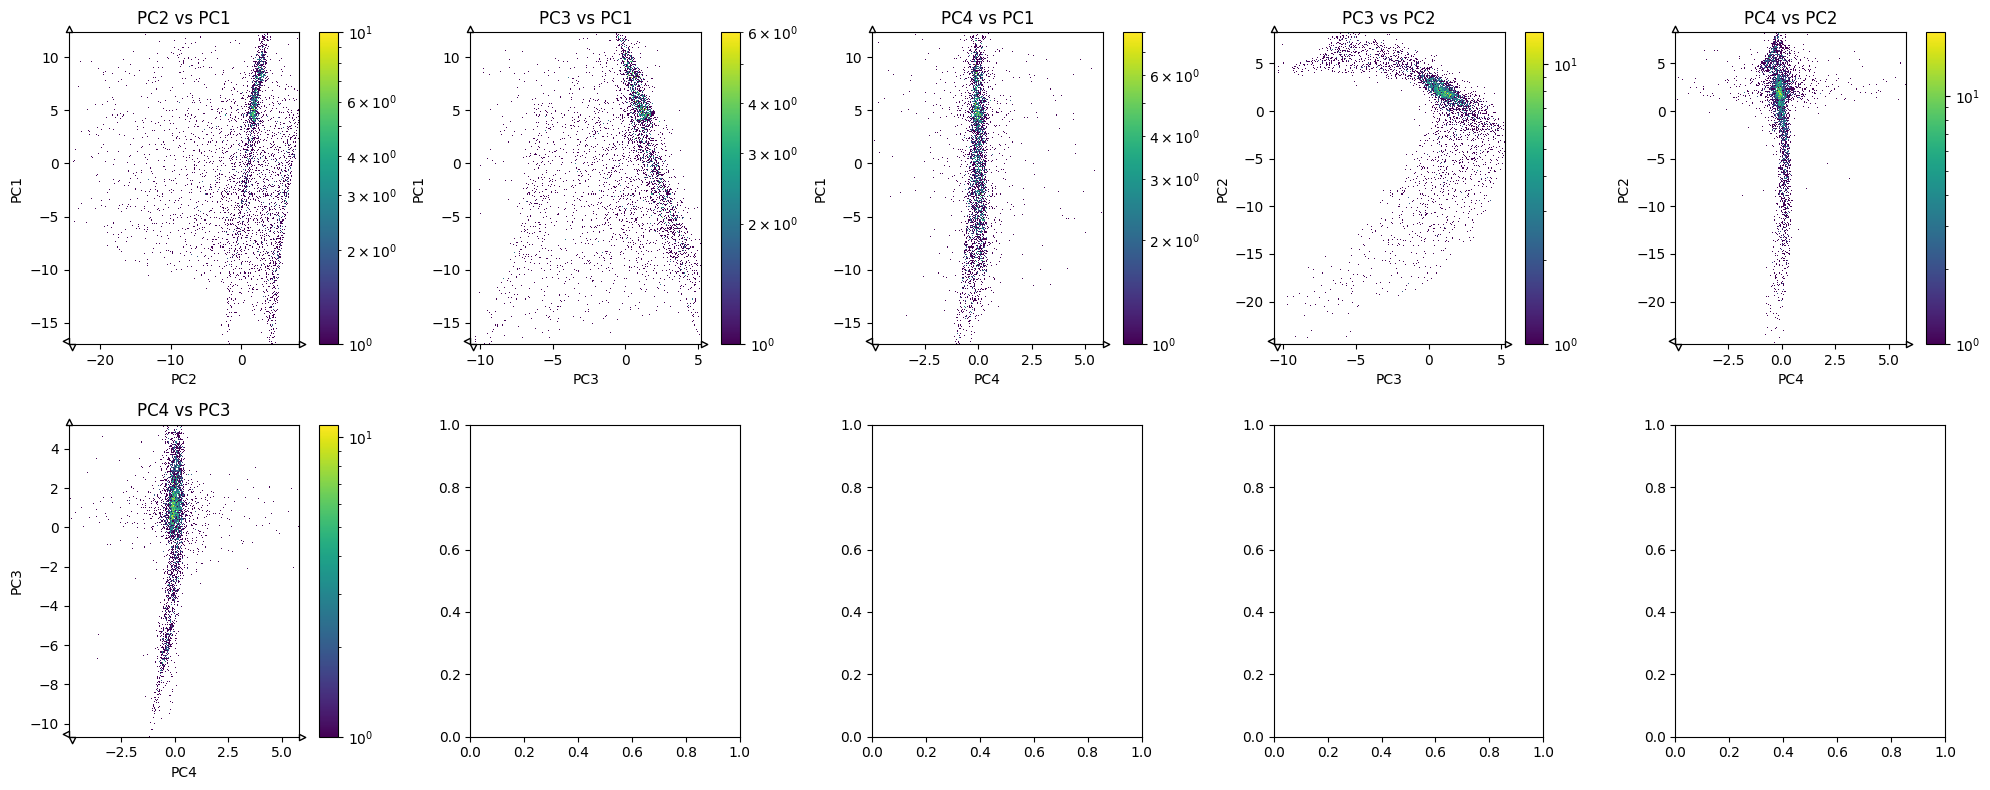

In [158]:
# PCA transform
pca_result = pca.transform(df_norm[num_cols])

pairs = list(itertools.combinations(range(n_comp), 2))

# layout (2 filas x 5 columnas = 10 plots)
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for ax, (i, j) in zip(axes.flatten(), pairs):
    
    pcx = pca_result[:, j]
    pcy = pca_result[:, i]
    
    # percentiles robustos
    xmin, xmax = np.percentile(pcx, [0.5, 99.5])
    ymin, ymax = np.percentile(pcy, [0.5, 99.5])
    
    # histograma 2D
    h2 = hist.Hist(
        hist.axis.Regular(300, xmin, xmax, name=f"PC{j+1}"),
        hist.axis.Regular(300, ymin, ymax, name=f"PC{i+1}")
    )
    
    h2.fill(**{f"PC{j+1}": pcx, f"PC{i+1}": pcy})
    
    # plot
    h2.plot(ax=ax, norm=mcolors.LogNorm(), cmap='viridis')
    
    ax.set_xlabel(f'PC{j+1}')
    ax.set_ylabel(f'PC{i+1}')
    ax.set_title(f'PC{j+1} vs PC{i+1}')

plt.tight_layout()
plt.show()

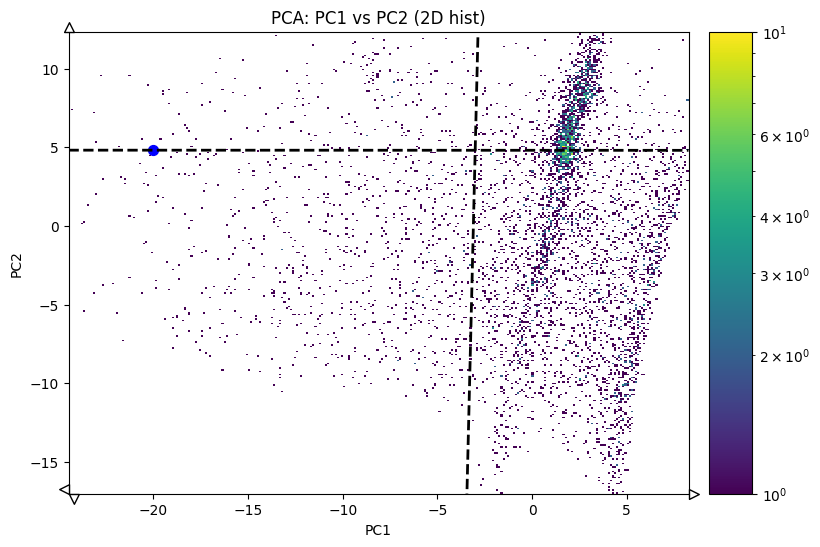

In [159]:
# 2D histogram of the two best PCA components using `hist`
pca_result = pca.transform(df_norm[num_cols])
pc1 = pca_result[:, 1]
pc2 = pca_result[:, 0]
# use robust percentile-driven ranges to avoid extreme outliers
xmin, xmax = np.percentile(pc1, [0.5, 99.5])
ymin, ymax = np.percentile(pc2, [0.5, 99.5])
# build a 2D hist with the `hist` package
h2 = hist.Hist(hist.axis.Regular(300, xmin, xmax, name="PC1"),
               hist.axis.Regular(300, ymin, ymax, name="PC2"))
h2.fill(PC1=pc1, PC2=pc2)
# draw with matplotlib (use pcolormesh from the histogram edges and values)
fig, ax = plt.subplots(figsize=(8,6))
h2.plot(ax=ax,norm=mcolors.LogNorm(), cmap='viridis')

# 🔴 puntos
p1 = (10, 4.8)
p2 = (-20, 4.81)

ax.scatter(*p1, color='red', s=50, label='Point 1')
ax.scatter(*p2, color='blue', s=50, label='Point 2')


# calcular recta
x1, y1 = p1
x2, y2 = p2

m = (y2 - y1) / (x2 - x1)
b = y1 - m * x1

# extender al rango del histograma
x_line = np.linspace(xmin, xmax, 500)
y_line = m * x_line + b

# otra recta diferente
p3 = (-3, 5)
p4 = (-3.1, 0)

#calcular la otra recta
x3, y3 = p3
x4, y4 = p4

m1 = (y4 - y3) / (x4 - x3)
b1 = y3 - m1 * x3

# extender al rango del histograma
x_line1 = np.linspace(xmin, xmax, 500)
y_line1 = m1 * x_line1 + b1

ax.plot(x_line, y_line, color='black', linewidth=2, linestyle='--')
ax.plot(x_line1, y_line1, color='black', linewidth=2, linestyle='--')

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('PCA: PC1 vs PC2 (2D hist)')
plt.show()

Selected events : 1300 (23.50 %)
Remaining events: 4231 (76.50 %)

Original dataframe: 5531 events
Selected dataframe: 1300 events
Rest dataframe:     4231 events


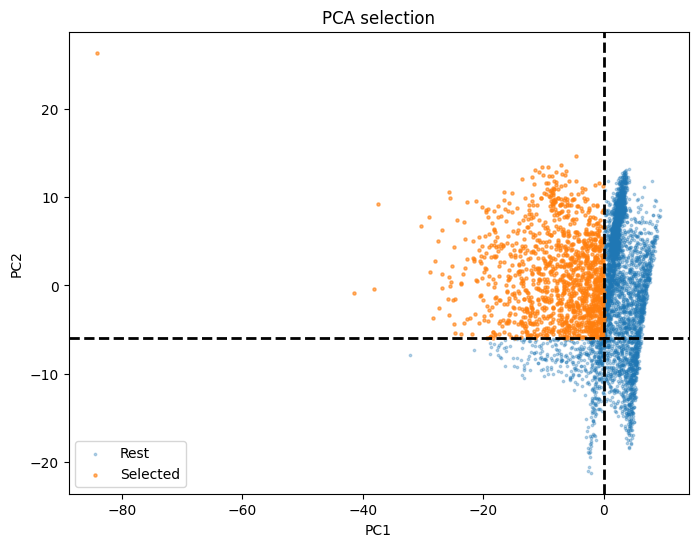

In [160]:
# ============================================================
# Masking based on the PCA selection
# ============================================================

# Limits defined by the two lines
x_cut = 0
y_cut = -6

# Region 1:
#   PC1 < x_cut  AND  PC2 > y_cut
mask_selected = (pc1 < x_cut) & (pc2 > y_cut)

# Region 2: everything else
mask_rest = ~mask_selected

# Apply masks to the original dataframe
df_selected = df_norm[mask_selected].copy()
df_rest = df_norm[mask_rest].copy()

print(f"Selected events : {mask_selected.sum()} ({100*mask_selected.mean():.2f} %)")
print(f"Remaining events: {mask_rest.sum()} ({100*mask_rest.mean():.2f} %)")

print(f"\nOriginal dataframe: {len(df_norm)} events")
print(f"Selected dataframe: {len(df_selected)} events")
print(f"Rest dataframe:     {len(df_rest)} events")

# ============================================================
# Visualize the selected and remaining events
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    pc1[mask_rest],
    pc2[mask_rest],
    s=3,
    alpha=0.3,
    label='Rest'
)

ax.scatter(
    pc1[mask_selected],
    pc2[mask_selected],
    s=5,
    alpha=0.6,
    label='Selected'
)

# Draw the cuts
ax.axvline(x_cut, color='black', linewidth=2, linestyle='--')
ax.axhline(y_cut, color='black', linewidth=2, linestyle='--')

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('PCA selection')
ax.legend()

plt.show()

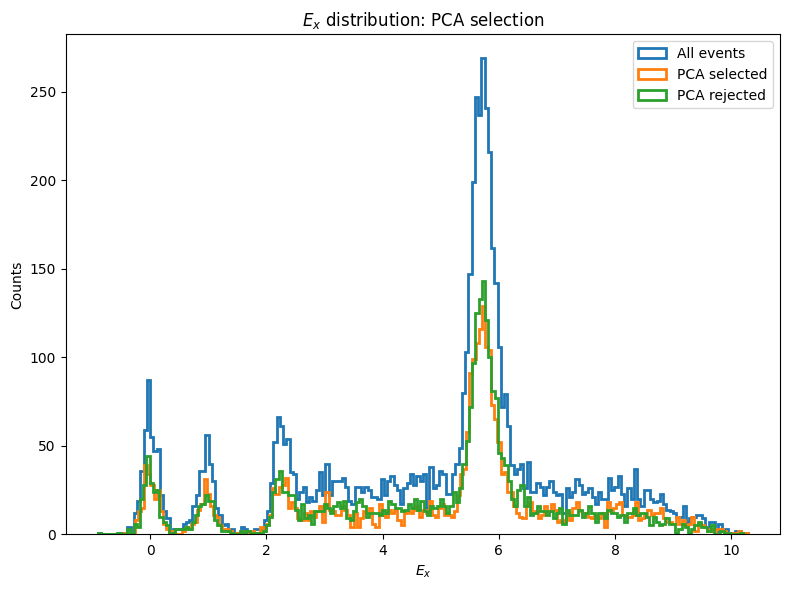

In [69]:
# ============================================================
# Ex distributions: selected vs non-selected PCA events
# ============================================================

Ex_all = tree["Ex"]
Ex_selected = tree.loc[mask_selected, "Ex"]
Ex_rest = tree.loc[mask_rest, "Ex"]

fig, ax = plt.subplots(figsize=(8, 6))

# All events
ax.hist(
    Ex_all,
    bins=200,
    histtype="step",
    linewidth=2,
    label="All events"
)

# PCA-selected events
ax.hist(
    Ex_selected,
    bins=200,
    histtype="step",
    linewidth=2,
    label="PCA selected"
)

# Events outside the PCA mask
ax.hist(
    Ex_rest,
    bins=200,
    histtype="step",
    linewidth=2,
    label="PCA rejected"
)

ax.set_xlabel(r"$E_x$")
ax.set_ylabel("Counts")
ax.set_title(r"$E_x$ distribution: PCA selection")
ax.legend()

plt.tight_layout()
plt.show()

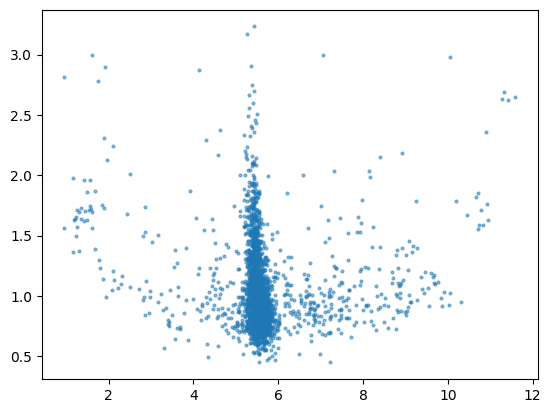

In [43]:
#Plot the kinematics (Theta vs TL) for the selected data
plt.plot(selected_data["fThetaLight"], selected_data["fLight_fTL"], 'o', markersize=2, alpha=0.5)

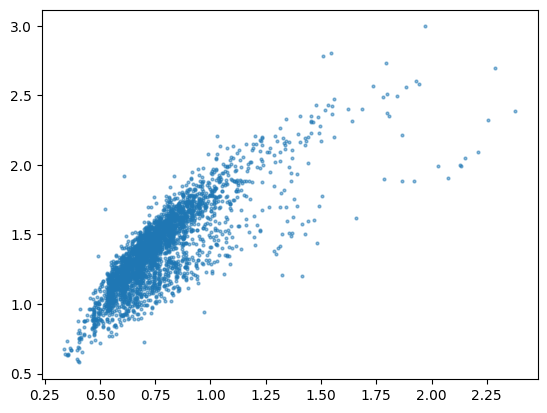

In [44]:
# Plot the PID
plt.plot(selected_data["fLight_fRawTL"], selected_data["fLight_fQtotal"], 'o', markersize=2, alpha=0.5)